In [3]:
import pandas as pd 

# Load the dataset (replace 'car_data.csv' with your actual file name)
df = pd.read_csv('Data/car data.csv')

#Look at the first 5 rows and print the columns
print("Columns in dataset:\n", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Columns in dataset:
 ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

First 3 rows:


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0


In [4]:
# 1. Check the shape of the dataset (Rows, Columns)
print(f"Dataset Shape: {df.shape}\n")

# 2. Get a sumary of columns, data types, and missing values
print("--- Data Info ---")
print(df.info())

# 3. Check the exact number of missing (null) values per column
print("\n--- Missing Values ----")
print(df.isnull().sum())

# 4. See statistical summary of numerical columns (mean, min, max, etc.)
print("\n--- Statitical Summary ----")
df.describe()

Dataset Shape: (301, 9)

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB
None

--- Missing Values ----
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

--- Statitical Summary ----


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [6]:
# 1. Calculate the age of the car (Current Year is 2026)
df['Car_Age'] = 2026-df['Year']

# 2. Drop the original 'Year' and 'Car_name' columns
df_cleaned = df.drop(columns=['Year', 'Car_Name'])

# 3. Apply one-Hot Encoding to categoriacl text columns
# 'droup_first='True' prevents multi-collinearity (dummy variable trap)
df_encoded = pd.get_dummies(df_cleaned, columns=['Fuel_Type', 'Selling_type', 'Transmission'], drop_first=True)

#Convert boolean True/False outputs from get_dummies to integers (1/0)
df_encoded = df_encoded.astype(int, errors='ignore')

# 4. View our new engineered dataset
print("New Dataset Columns:\n", df_encoded.columns.tolist())
print("\nFirst 3 rows of processed data:")
df_encoded.head(3)

New Dataset Columns:
 ['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual']

First 3 rows of processed data:


,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3,5,27000,0,12,0,1,0,1
1,4,9,43000,0,13,1,0,0,1
2,7,9,6900,0,9,0,1,0,1


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Separate target variable (y) and input features (x)
X = df_encoded.drop(columns=['Selling_Price'])
y = df_encoded['Selling_Price']

# 2. Split the data into 80% Training and 20% Teasting sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Traing set size: {X_train.shape[0]} samples")
print("fTesting set size: {X_test.shape[0]} samples\n")
 # 3. Initialize and train a baseline Linear Regression model

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

Traing set size: 240 samples
fTesting set size: {X_test.shape[0]} samples



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.43,-0. ,-0.87,..., 0.94,-1.06,-1.63]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Present_Price','Driven_kms','Owner',...,'Fuel_Type_Petrol', 'Selling_type_Individual','Transmission_Manual']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.224
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


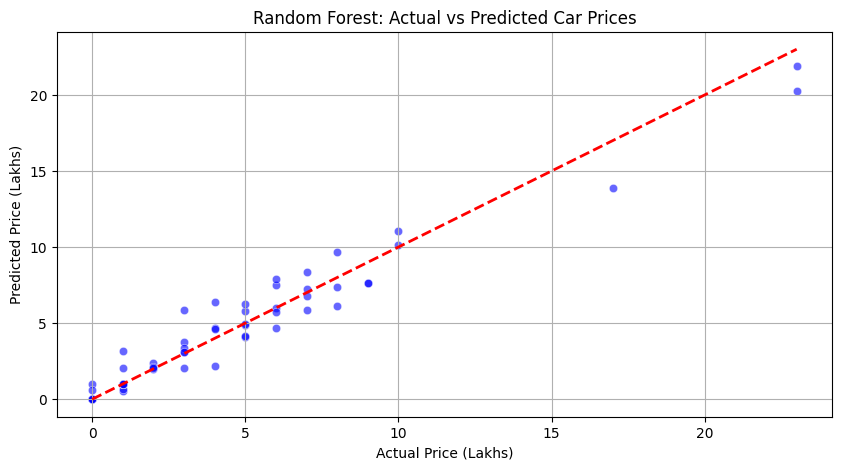

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize and train a more advanced Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict using the random Forest model
y_pred_rf = rf_model.predict(X_test)

# 3. Evaluate Random Forest Performance
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# 4. Plotting Actual vs Predicted prices side-by-side
plt.figure(figsize=(10,5))
sns.scatterplot(x=y_test, y=y_pred_rf, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('Random Forest: Actual vs Predicted Car Prices')
plt.grid(True)
plt.show()



In [11]:
import pickle
 # Save the trained Random Forest model to a file

with open('car_price_model.pkl', 'wb') as file:
    pickle.dump(rf_model,file)
print("Model successfully saved as 'car_preice_model.pkl'!")


Model successfully saved as 'car_preice_model.pkl'!
